In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from colorspacious import cspace_converter
import numpy as np

cmaps = [('Perceptually Uniform Sequential', [
            'viridis', 'plasma', 'inferno', 'magma', 'cividis']),
         ('Sequential', [
            'Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
            'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
            'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']),
         ('Sequential (2)', [
            'binary', 'gist_yarg', 'gist_gray', 'gray', 'bone', 'pink',
            'spring', 'summer', 'autumn', 'winter', 'cool', 'Wistia',
            'hot', 'afmhot', 'gist_heat', 'copper']),
         ('Diverging', [
            'PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu',
            'RdYlBu', 'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic',
            'berlin', 'managua', 'vanimo']),
         ('Cyclic', ['twilight', 'twilight_shifted', 'hsv']),
         ('Qualitative', [
            'Pastel1', 'Pastel2', 'Paired', 'Accent',
            'Dark2', 'Set1', 'Set2', 'Set3',
            'tab10', 'tab20', 'tab20b', 'tab20c']),
         ('Miscellaneous', [
            'flag', 'prism', 'ocean', 'gist_earth', 'terrain', 'gist_stern',
            'gnuplot', 'gnuplot2', 'CMRmap', 'cubehelix', 'brg',
            'gist_rainbow', 'rainbow', 'jet', 'turbo', 'nipy_spectral',
            'gist_ncar'])]

# Load CSVs
normal = pd.read_csv("qualitycriteria.csv")
copilot = pd.read_csv("qualitycriteriaCopilot.csv")
chatgpt = pd.read_csv("qualitycriteriaChatGPT.csv")
chatgpt2 = pd.read_csv("qualitycriteriaChatGPT2.csv")
deepseek = pd.read_csv("qualitycriteriaDeepseek.csv")

# Set index
normal = normal.set_index("cartogram_type")
copilot = copilot.set_index("cartogram_type")
chatgpt = chatgpt.set_index("cartogram_type")
chatgpt2 = chatgpt2.set_index("cartogram_type")
deepseek = deepseek.set_index("cartogram_type")

# Convert values to numeric (in case of whitespace)
normal = normal.apply(pd.to_numeric)
copilot = copilot.apply(pd.to_numeric)
chatgpt = chatgpt.apply(pd.to_numeric)
chatgpt2 = chatgpt2.apply(pd.to_numeric)
deepseek = deepseek.apply(pd.to_numeric)

# Average the AI evaluations
ai_avg = (copilot + chatgpt + chatgpt2 + deepseek) / 4

# Combine 50% AI average with 50% normal dataset
combined = (ai_avg * 0.5) + (normal * 0.5)
combined = (combined - combined.min()) / (combined.max() - combined.min())

# Prepare for parallel coordinates
plot_df = combined.reset_index()
normal = normal.reset_index()

# print(plot_df.head())

def parallel_plot(df, title, colormap = plt.cm.Set1, alpha=0.5, linestyle=None, linewidth=3, jitter=0.0):
   df_plot = df.copy()

   for index, row in df_plot.iterrows():
      rand_offset = np.random.uniform(-jitter, jitter)   # one random value per row
      df_plot.loc[index, df_plot.columns[1:]] += rand_offset


   plt.figure(figsize=(12,6))
   parallel_coordinates(df_plot, "cartogram_type", colormap=colormap, alpha=alpha,linestyle=linestyle, linewidth=linewidth)

   plt.xticks(rotation=45)
   plt.ylabel("Score")
   plt.title(title)
   plt.grid(True)
   plt.tight_layout()

   plt.show()

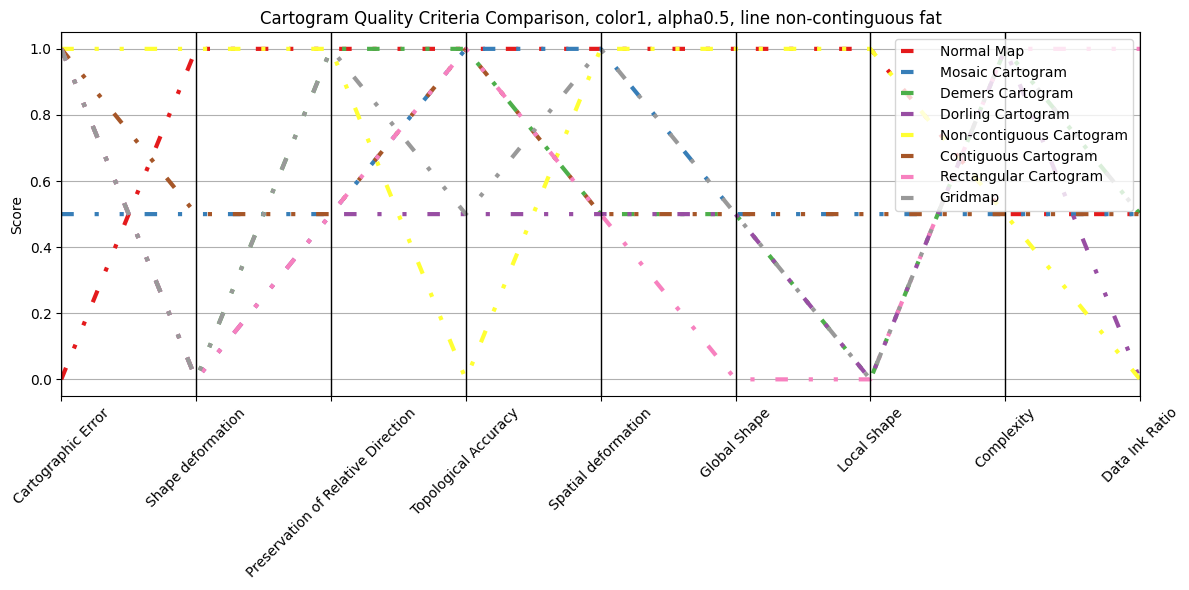

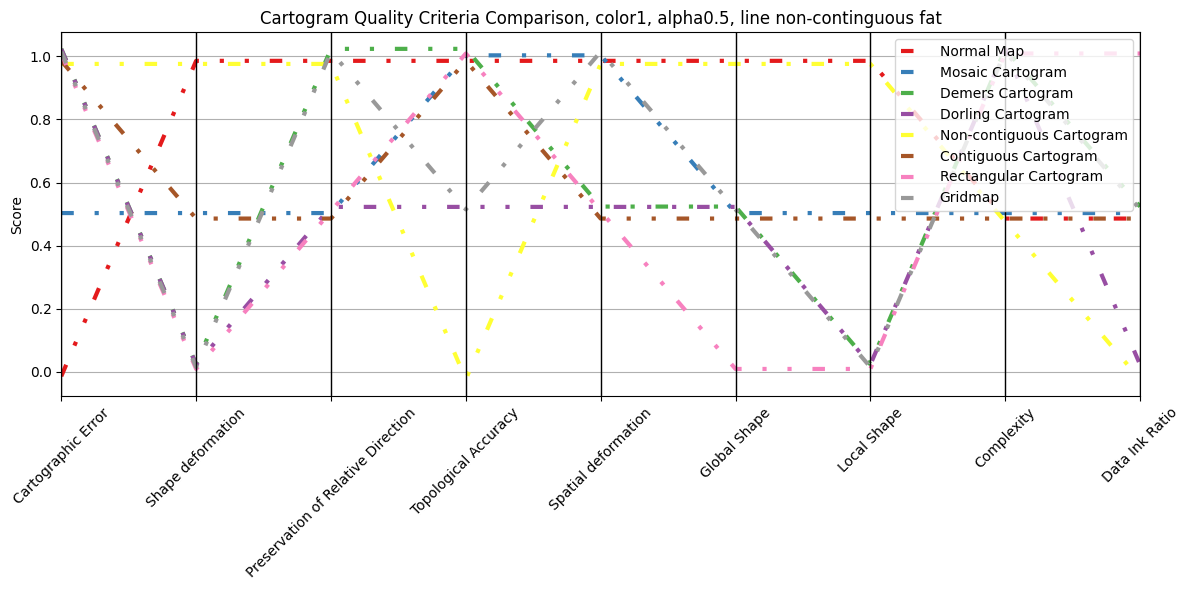

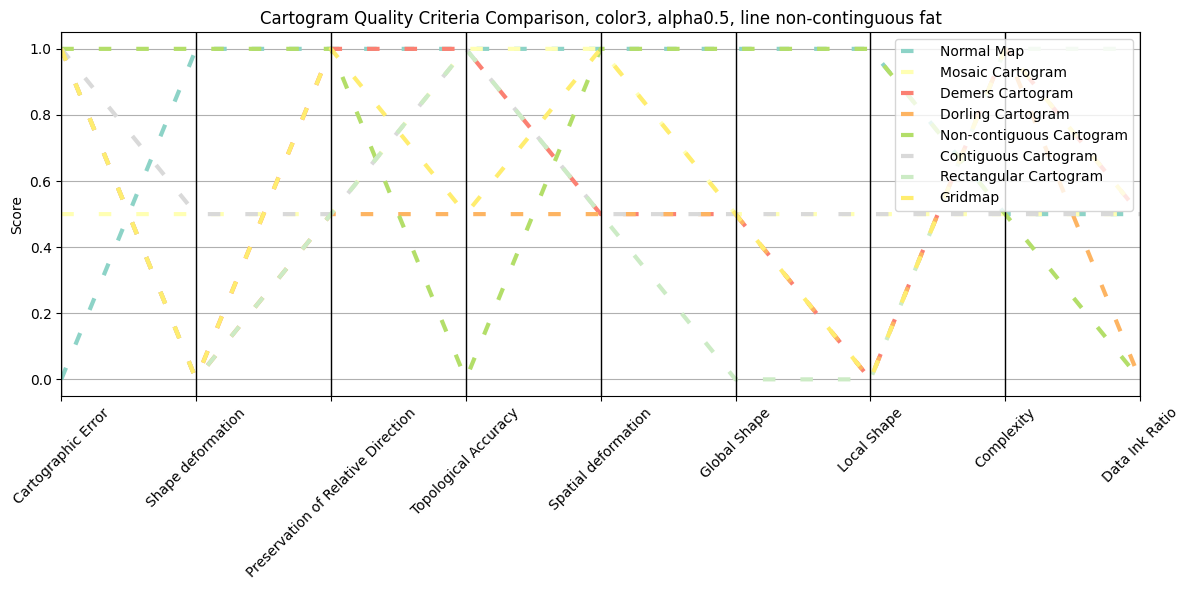

In [80]:
parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color1, alpha0.5, line non-continguous fat", colormap=plt.cm.Set1, alpha=1, linestyle=(0, (3, 5, 1, 5, 1, 5)), linewidth=3, jitter=0)

parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color1, alpha0.5, line non-continguous fat", colormap=plt.cm.Set1, alpha=1, linestyle=(0, (3, 5, 1, 5, 1, 5)), linewidth=3, jitter=0.025)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color1, alpha0.5, line non-continguous thin", colormap=plt.cm.Set1, alpha=0.5, linestyle=(0, (3, 6)), linewidth=1)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color1, alpha0.5, line contiguous", colormap=plt.cm.Set1, alpha=0.5, linestyle=None, linewidth=3)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color1, alpha1, line contiguous", colormap=plt.cm.Set1, alpha=1, linestyle=None, linewidth=3)

# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color2, alpha0.5, line non-continguous fat", colormap=plt.cm.Set2, alpha=0.5, linestyle=(0, (3, 6)), linewidth=3)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color2, alpha0.5, line non-continguous thin", colormap=plt.cm.Set2, alpha=0.5, linestyle=(0, (3, 6)), linewidth=1)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color2, alpha0.5, line contiguous", colormap=plt.cm.Set2, alpha=0.5, linestyle=None, linewidth=3)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color2, alpha1, line contiguous", colormap=plt.cm.Set2, alpha=1, linestyle=None, linewidth=3)

parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color3, alpha0.5, line non-continguous fat", colormap=plt.cm.Set3, alpha=1, linestyle=(0, (3, 6)), linewidth=3)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color3, alpha0.5, line non-continguous thin", colormap=plt.cm.Set3, alpha=0.5, linestyle=(0, (3, 6)), linewidth=1)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color3, alpha0.5, line contiguous", colormap=plt.cm.Set3, alpha=0.5, linestyle=None, linewidth=3)
# parallel_plot(normal, title="Cartogram Quality Criteria Comparison, color3, alpha1, line contiguous", colormap=plt.cm.Set3, alpha=1, linestyle=None, linewidth=3)